# Notebook 03 — SmallCNN (3 conv layers)

**არქიტექტურა #2: საშუალო ზომის CNN, 3 conv layers**

TinyCNN-ის შემდეგ ვამატებთ მეტ depth-ს და filter-ებს. capacity გაცილებით მაღალია (~500K params vs 32K).

**სტრუქტურა:**
- Block 1: Conv(1→32) → ReLU → MaxPool → (32, 24, 24)
- Block 2: Conv(32→64) → ReLU → MaxPool → (64, 12, 12)
- Block 3: Conv(64→128) → ReLU → MaxPool → (128, 6, 6)
- FC: 4608 → 128 → 7

**ექსპერიმენტები:**
1. Run A — 15 epochs, Adam lr=1e-3, no regularization (baseline)
2. Run B — 30 epochs (იგივე setup) → მოსალოდნელია overfitting demonstration
3. Run C — 15 epochs + L2 weight decay → ცდა overfit-ის შესამცირებლად


In [1]:
# Setup
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os
PROJECT_DIR = '/content/drive/MyDrive/ML_davaleba_4'
os.chdir(PROJECT_DIR)

import sys
sys.path.insert(0, f'{PROJECT_DIR}/src')

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import wandb

from utils import (
    load_fer2013, get_dataloaders, count_parameters,
    sanity_check_forward, sanity_check_overfit_batch,
    train_model, evaluate, plot_training_curves,
    get_predictions, plot_confusion_matrix, print_classification_report,
    set_seed,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Mounted at /content/drive
Device: cuda


In [2]:
# WandB login
try:
    from google.colab import userdata
    WANDB_API_KEY = userdata.get('WANDB_API_KEY')
except Exception:
    WANDB_API_KEY = "API_KEY"

wandb.login(key=WANDB_API_KEY)
PROJECT = "ml_davaleba_4"

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: zberi23 (zberi23_ml) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [3]:
# Data loading
X_train, y_train, X_val, y_val, X_test, y_test = load_fer2013(
    f'{PROJECT_DIR}/data/fer2013_processed.npz'
)

BATCH_SIZE = 64
train_loader, val_loader, test_loader = get_dataloaders(
    X_train, y_train, X_val, y_val, X_test, y_test,
    batch_size=BATCH_SIZE, num_workers=2
)
print(f"Train batches: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Train batches: 449, Val: 57, Test: 57


## SmallCNN — Architecture #2

ვამატებთ depth-ს — 3 conv block, each with doubling filter count.


In [4]:
class SmallCNN(nn.Module):
    """3-block CNN, no batchnorm, no dropout — capacity to overfit."""
    def __init__(self, num_classes=7):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                              # (32, 24, 24)

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                              # (64, 12, 12)

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                              # (128, 6, 6)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


set_seed(42)
model = SmallCNN().to(device)
print(model)
print(f"\nTrainable parameters: {count_parameters(model):,}")

SmallCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4608, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=128, out_features=7, bias=True)
  )
)

Trainable parameters: 683,527


## Sanity Checks

In [5]:
# Forward pass sanity
criterion = nn.CrossEntropyLoss()
_ = sanity_check_forward(model, train_loader, criterion, device)

=== Forward Pass Sanity Check ===
  Batch input shape:  (64, 1, 48, 48)
  Batch output shape: (64, 7)
  Initial loss:       1.9503
  Expected (random):  1.9459  = log(7)
  Diff:               0.0044
  Trainable params:   683,527


In [6]:
# Single batch overfit
set_seed(42)
sanity_model = SmallCNN().to(device)
sanity_opt = optim.Adam(sanity_model.parameters(), lr=1e-3)
_ = sanity_check_overfit_batch(sanity_model, train_loader, sanity_opt, criterion, device, num_steps=150)

=== Overfit Single Batch Sanity Check (150 steps) ===
  Step    0 | loss 1.9503 | acc 0.1250
  Step   15 | loss 1.4506 | acc 0.5000
  Step   30 | loss 0.6733 | acc 0.7969
  Step   45 | loss 0.0590 | acc 1.0000
  Step   60 | loss 0.0030 | acc 1.0000
  Step   75 | loss 0.0005 | acc 1.0000
  Step   90 | loss 0.0003 | acc 1.0000
  Step  105 | loss 0.0002 | acc 1.0000
  Step  120 | loss 0.0002 | acc 1.0000
  Step  135 | loss 0.0001 | acc 1.0000
  Step  149 | loss 0.0001 | acc 1.0000
  Final batch accuracy: 1.0000
  Model can overfit a single batch - capacity OK


## Run A — Baseline (15 epochs, Adam, lr=1e-3)

baseline training without regularization. ველოდებით ბევრად უკეთეს accuracy-ს ვიდრე TinyCNN-ი.


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch   1/15 | train_loss 1.6852 acc 0.3266 | val_loss 1.5158 acc 0.4218 | grad 1.264 | lr 1.00e-03
Epoch   2/15 | train_loss 1.4432 acc 0.4441 | val_loss 1.3802 acc 0.4681 | grad 2.058 | lr 1.00e-03
Epoch   3/15 | train_loss 1.3091 acc 0.4981 | val_loss 1.3371 acc 0.4876 | grad 2.463 | lr 1.00e-03
Epoch   4/15 | train_loss 1.2137 acc 0.5378 | val_loss 1.2572 acc 0.5235 | grad 2.572 | lr 1.00e-03
Epoch   5/15 | train_loss 1.1391 acc 0.5701 | val_loss 1.2184 acc 0.5322 | grad 2.782 | lr 1.00e-03
Epoch   6/15 | train_loss 1.0649 acc 0.5973 | val_loss 1.2013 acc 0.5514 | grad 2.869 | lr 1.00e-03
Epoch   7/15 | train_loss 0.9951 acc 0.6295 | val_loss 1.2233 acc 0.5397 | grad 3.086 | lr 1.00e-03
Epoch   8/15 | train_loss 0.9262 acc 0.6558 | val_loss 1.2048 acc 0.5559 | grad 3.162 | lr 1.00e-03
Epoch   9/15 | train_loss 0.8583 acc 0.6820 | val_loss 1.2194 acc 0.5651 | grad 3.274 | lr 1.00e-03
Epoch  10/15 | train_loss 0.7923 acc 0.7059 | val_loss 1.2623 acc 0.5637 | grad 3.475 | lr 1.00e-03


best_val_acc,▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
grad_norm,▁▃▄▄▅▅▅▅▆▆▆▇▇██
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▃▃▄▄▅▅▆▆▆▇▇▇██
train_loss,█▇▆▅▅▄▄▄▃▃▂▂▂▁▁
val_acc,▁▃▄▆▆▇▇▇███▇█▇▇
val_loss,▅▃▃▂▁▁▁▁▁▂▃▄▅▆█
best_val_acc,0.5698
epoch,15
grad_norm,4.21918


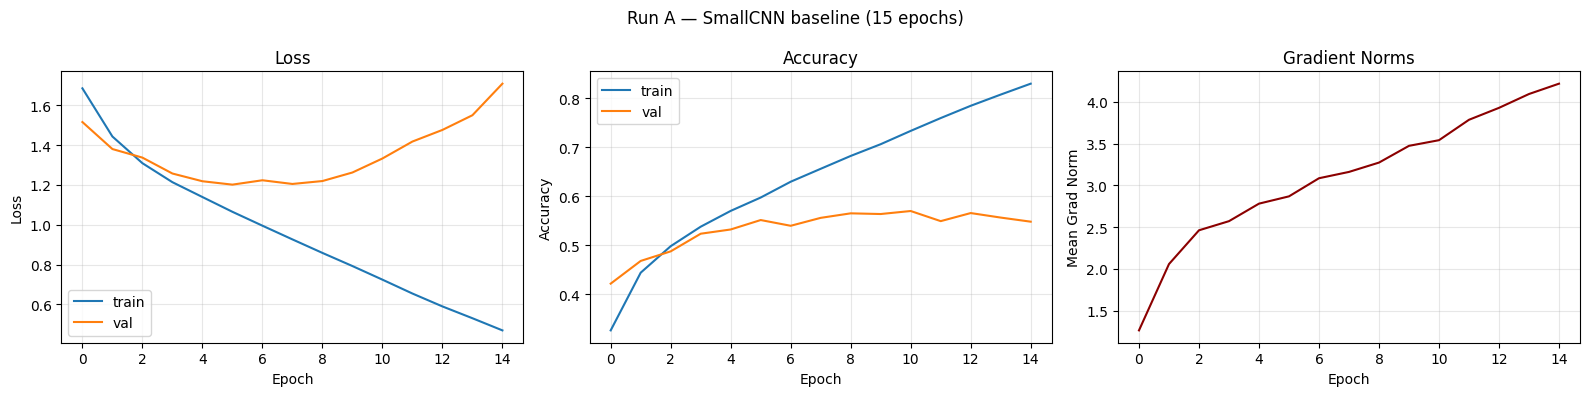

Best val acc: 0.5698


In [7]:
# Run A — 15 epochs baseline
set_seed(42)
model_a = SmallCNN().to(device)
optimizer_a = optim.Adam(model_a.parameters(), lr=1e-3)

config_a = {
    'architecture': 'SmallCNN',
    'num_params': count_parameters(model_a),
    'optimizer': 'Adam',
    'lr': 1e-3,
    'weight_decay': 0,
    'batch_size': BATCH_SIZE,
    'num_epochs': 15,
    'regularization': 'none',
}

history_a, best_acc_a = train_model(
    model_a, train_loader, val_loader, optimizer_a, criterion, device,
    num_epochs=15, run_name='03_smallcnn_baseline',
    project=PROJECT, config=config_a,
    save_path=f'{PROJECT_DIR}/models/03_smallcnn_baseline.pt'
)
wandb.finish()
plot_training_curves(history_a, title="Run A — SmallCNN baseline (15 epochs)")
print(f"Best val acc: {best_acc_a:.4f}")

## Run B — Overfit demonstration (30 epochs, no regularization)

იგივე setup, მაგრამ 2-ჯერ მეტი epoch. ველოდებით train_acc-ი მაღლა გავა, val_acc plateau-დან დაიწყებს ჩამოვარდნას — **overfitting**.


Epoch   1/30 | train_loss 1.6852 acc 0.3266 | val_loss 1.5158 acc 0.4218 | grad 1.264 | lr 1.00e-03
Epoch   2/30 | train_loss 1.4432 acc 0.4441 | val_loss 1.3802 acc 0.4681 | grad 2.058 | lr 1.00e-03
Epoch   3/30 | train_loss 1.3091 acc 0.4981 | val_loss 1.3371 acc 0.4876 | grad 2.463 | lr 1.00e-03
Epoch   4/30 | train_loss 1.2137 acc 0.5378 | val_loss 1.2572 acc 0.5235 | grad 2.572 | lr 1.00e-03
Epoch   5/30 | train_loss 1.1391 acc 0.5701 | val_loss 1.2184 acc 0.5322 | grad 2.782 | lr 1.00e-03
Epoch   6/30 | train_loss 1.0649 acc 0.5973 | val_loss 1.2013 acc 0.5514 | grad 2.869 | lr 1.00e-03
Epoch   7/30 | train_loss 0.9951 acc 0.6295 | val_loss 1.2233 acc 0.5397 | grad 3.086 | lr 1.00e-03
Epoch   8/30 | train_loss 0.9262 acc 0.6558 | val_loss 1.2048 acc 0.5559 | grad 3.162 | lr 1.00e-03
Epoch   9/30 | train_loss 0.8583 acc 0.6820 | val_loss 1.2194 acc 0.5651 | grad 3.274 | lr 1.00e-03
Epoch  10/30 | train_loss 0.7923 acc 0.7059 | val_loss 1.2623 acc 0.5637 | grad 3.475 | lr 1.00e-03


best_val_acc,▁
epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
grad_norm,▁▃▄▄▄▄▅▅▅▆▆▆▇▇▇█▇█████▇▇█▇█▇▇█
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▂▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇▇▇██████████
train_loss,█▇▆▆▆▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▄▆▆▇▇▇███▇█▇▇█▇▇▆▇▇▇▇▇▆▇▆▇▆▇
val_loss,▂▂▁▁▁▁▁▁▁▁▁▂▂▂▂▃▃▄▄▅▅▅▆▆▇▇▇███
best_val_acc,0.5698
epoch,30
grad_norm,4.30055


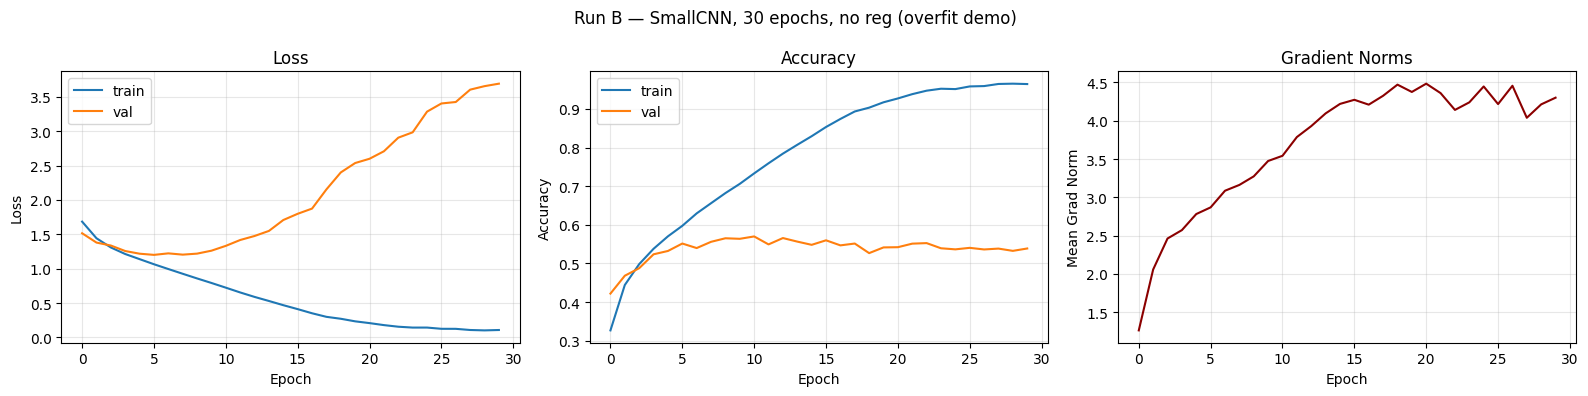

Best val acc: 0.5698
Train acc (last epoch): 0.9643
Val acc (last epoch): 0.5386
Train-Val gap: 0.4257


In [8]:
# Run B — 30 epochs, no regularization (overfit demo)
set_seed(42)
model_b = SmallCNN().to(device)
optimizer_b = optim.Adam(model_b.parameters(), lr=1e-3)

config_b = {
    'architecture': 'SmallCNN',
    'num_params': count_parameters(model_b),
    'optimizer': 'Adam',
    'lr': 1e-3,
    'weight_decay': 0,
    'batch_size': BATCH_SIZE,
    'num_epochs': 30,
    'regularization': 'none',
    'notes': 'overfit_demo',
}

history_b, best_acc_b = train_model(
    model_b, train_loader, val_loader, optimizer_b, criterion, device,
    num_epochs=30, run_name='03_smallcnn_overfit_30ep',
    project=PROJECT, config=config_b,
    save_path=f'{PROJECT_DIR}/models/03_smallcnn_overfit.pt'
)
wandb.finish()
plot_training_curves(history_b, title="Run B — SmallCNN, 30 epochs, no reg (overfit demo)")
print(f"Best val acc: {best_acc_b:.4f}")
print(f"Train acc (last epoch): {history_b['train_acc'][-1]:.4f}")
print(f"Val acc (last epoch): {history_b['val_acc'][-1]:.4f}")
print(f"Train-Val gap: {history_b['train_acc'][-1] - history_b['val_acc'][-1]:.4f}")

## Run C — L2 weight decay (regularization attempt)

ვცდილობთ overfit-ის შემცირებას weight_decay parameter-ით (L2 regularization Adam-ში).


Epoch   1/20 | train_loss 1.6948 acc 0.3200 | val_loss 1.5231 acc 0.4202 | grad 1.230 | lr 1.00e-03
Epoch   2/20 | train_loss 1.4563 acc 0.4365 | val_loss 1.3976 acc 0.4695 | grad 1.966 | lr 1.00e-03
Epoch   3/20 | train_loss 1.3195 acc 0.4955 | val_loss 1.3274 acc 0.4921 | grad 2.372 | lr 1.00e-03
Epoch   4/20 | train_loss 1.2253 acc 0.5377 | val_loss 1.2540 acc 0.5177 | grad 2.539 | lr 1.00e-03
Epoch   5/20 | train_loss 1.1559 acc 0.5606 | val_loss 1.2154 acc 0.5316 | grad 2.709 | lr 1.00e-03
Epoch   6/20 | train_loss 1.0849 acc 0.5925 | val_loss 1.1916 acc 0.5508 | grad 2.851 | lr 1.00e-03
Epoch   7/20 | train_loss 1.0247 acc 0.6159 | val_loss 1.1923 acc 0.5469 | grad 2.905 | lr 1.00e-03
Epoch   8/20 | train_loss 0.9616 acc 0.6417 | val_loss 1.1906 acc 0.5637 | grad 3.031 | lr 1.00e-03
Epoch   9/20 | train_loss 0.8921 acc 0.6703 | val_loss 1.1896 acc 0.5617 | grad 3.120 | lr 1.00e-03
Epoch  10/20 | train_loss 0.8370 acc 0.6896 | val_loss 1.2165 acc 0.5612 | grad 3.314 | lr 1.00e-03


best_val_acc,▁
epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
grad_norm,▁▃▄▄▄▅▅▅▅▆▆▆▇▇▇█████
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▂▃▄▄▄▅▅▅▆▆▆▆▇▇▇▇███
train_loss,█▇▆▆▅▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁
val_acc,▁▃▄▆▆▇▇███████▇▇▇▇▇▇
val_loss,▃▂▂▁▁▁▁▁▁▁▂▂▂▃▃▄▅▆▆█
best_val_acc,0.57035
epoch,20
grad_norm,4.34142


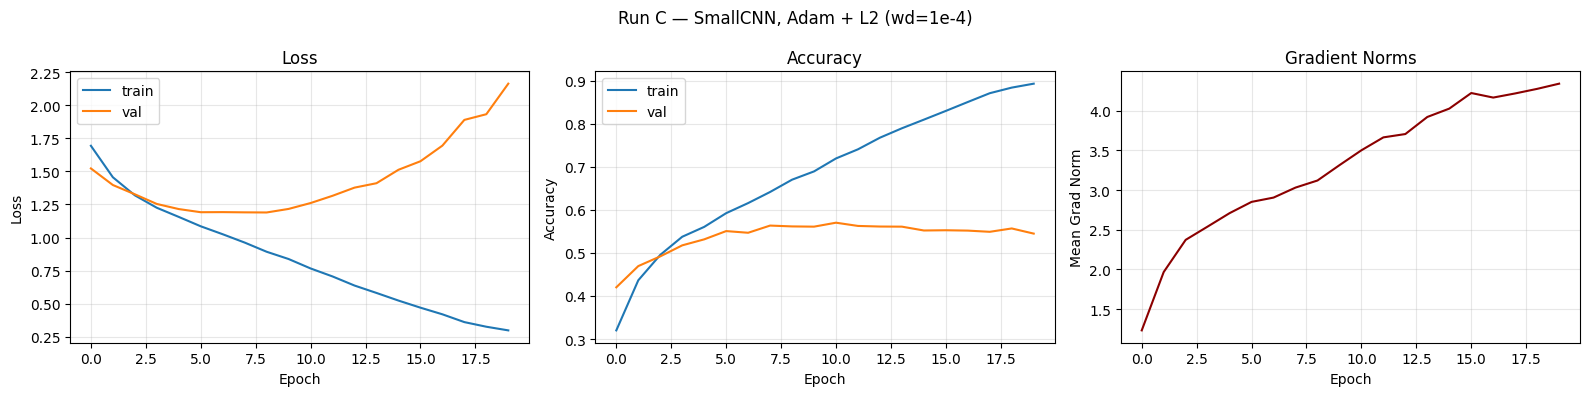

Best val acc: 0.5704


In [9]:
# Run C — Adam with weight_decay=1e-4
set_seed(42)
model_c = SmallCNN().to(device)
optimizer_c = optim.Adam(model_c.parameters(), lr=1e-3, weight_decay=1e-4)

config_c = {
    'architecture': 'SmallCNN',
    'num_params': count_parameters(model_c),
    'optimizer': 'Adam',
    'lr': 1e-3,
    'weight_decay': 1e-4,
    'batch_size': BATCH_SIZE,
    'num_epochs': 20,
    'regularization': 'L2',
}

history_c, best_acc_c = train_model(
    model_c, train_loader, val_loader, optimizer_c, criterion, device,
    num_epochs=20, run_name='03_smallcnn_l2reg',
    project=PROJECT, config=config_c,
    save_path=f'{PROJECT_DIR}/models/03_smallcnn_l2.pt'
)
wandb.finish()
plot_training_curves(history_c, title="Run C — SmallCNN, Adam + L2 (wd=1e-4)")
print(f"Best val acc: {best_acc_c:.4f}")

## Run-ების შედარება

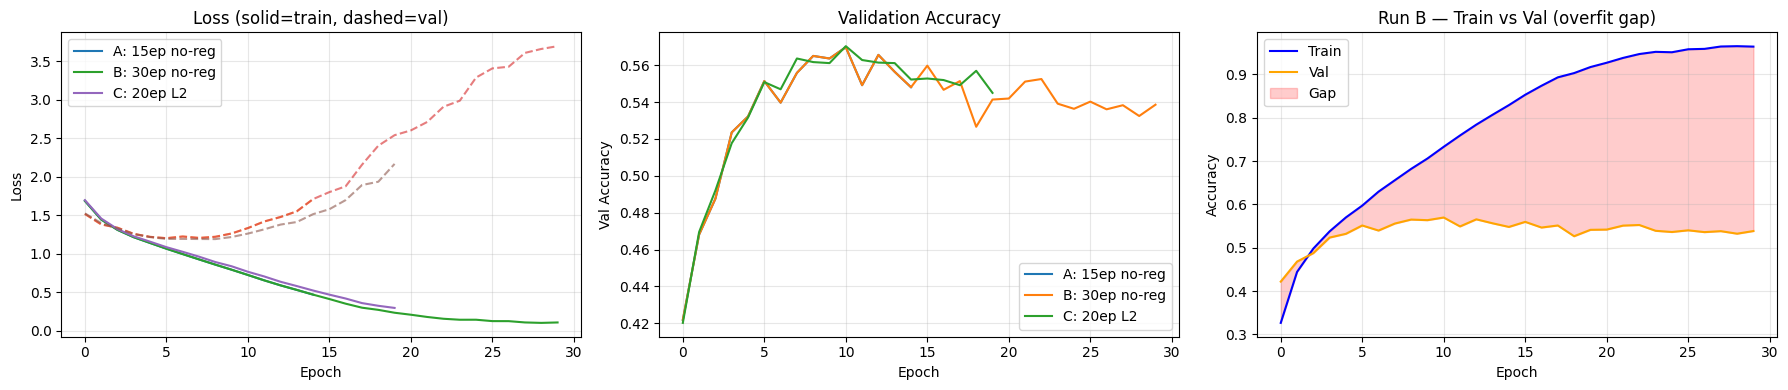


Final val accuracy comparison:
  Run A (15ep, no reg):    0.5698
  Run B (30ep, no reg):    0.5698  [final train: 0.9643]
  Run C (20ep, L2 wd=1e-4): 0.5704


In [10]:
# 3 run-ის შედარების plot
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history_a['train_loss'], label='A: 15ep no-reg', linestyle='-')
axes[0].plot(history_a['val_loss'], linestyle='--', alpha=0.6)
axes[0].plot(history_b['train_loss'], label='B: 30ep no-reg', linestyle='-')
axes[0].plot(history_b['val_loss'], linestyle='--', alpha=0.6)
axes[0].plot(history_c['train_loss'], label='C: 20ep L2', linestyle='-')
axes[0].plot(history_c['val_loss'], linestyle='--', alpha=0.6)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss (solid=train, dashed=val)'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_a['val_acc'], label='A: 15ep no-reg')
axes[1].plot(history_b['val_acc'], label='B: 30ep no-reg')
axes[1].plot(history_c['val_acc'], label='C: 20ep L2')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Accuracy')
axes[1].set_title('Validation Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

# Run B-ის train vs val gap-ი - overfit-ის ვიზუალიზაცია
axes[2].plot(history_b['train_acc'], label='Train', color='blue')
axes[2].plot(history_b['val_acc'], label='Val', color='orange')
axes[2].fill_between(range(len(history_b['train_acc'])),
                      history_b['train_acc'], history_b['val_acc'],
                      alpha=0.2, color='red', label='Gap')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Accuracy')
axes[2].set_title('Run B — Train vs Val (overfit gap)'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"\nFinal val accuracy comparison:")
print(f"  Run A (15ep, no reg):    {best_acc_a:.4f}")
print(f"  Run B (30ep, no reg):    {best_acc_b:.4f}  [final train: {history_b['train_acc'][-1]:.4f}]")
print(f"  Run C (20ep, L2 wd=1e-4): {best_acc_c:.4f}")

## საუკეთესო Run-ის Test Evaluation

საუკეთესო Run: C (val_acc=0.5704)

Test loss: 1.2516
Test accuracy: 0.5645


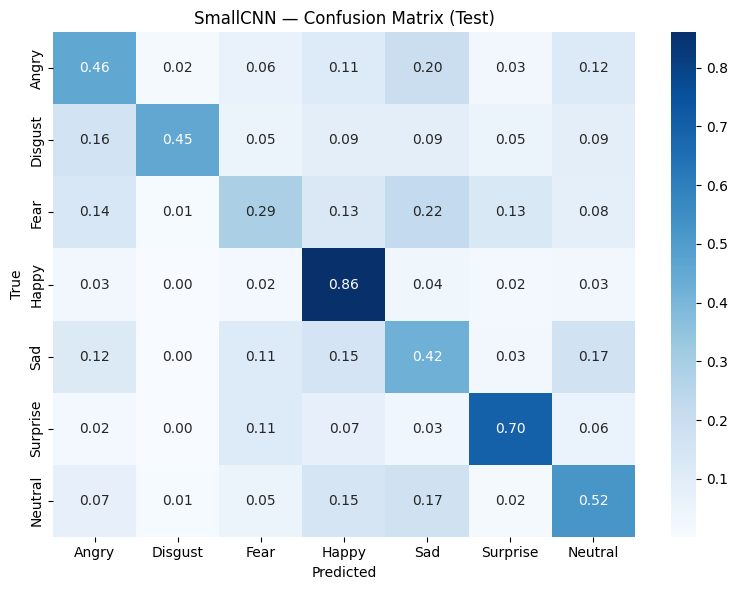

              precision    recall  f1-score   support

       Angry     0.4945    0.4603    0.4768       491
     Disgust     0.4902    0.4545    0.4717        55
        Fear     0.4318    0.2879    0.3455       528
       Happy     0.6879    0.8601    0.7644       879
         Sad     0.4013    0.4209    0.4108       594
    Surprise     0.6856    0.6971    0.6913       416
     Neutral     0.5599    0.5224    0.5405       626

    accuracy                         0.5645      3589
   macro avg     0.5359    0.5290    0.5287      3589
weighted avg     0.5507    0.5645    0.5529      3589



In [11]:
# საუკეთესოს არჩევა best_val_acc-ით
best_runs = {
    'A': (best_acc_a, f'{PROJECT_DIR}/models/03_smallcnn_baseline.pt'),
    'B': (best_acc_b, f'{PROJECT_DIR}/models/03_smallcnn_overfit.pt'),
    'C': (best_acc_c, f'{PROJECT_DIR}/models/03_smallcnn_l2.pt'),
}
best_label = max(best_runs, key=lambda k: best_runs[k][0])
best_acc, best_path = best_runs[best_label]
print(f"საუკეთესო Run: {best_label} (val_acc={best_acc:.4f})")

best_model = SmallCNN().to(device)
best_model.load_state_dict(torch.load(best_path))

test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)
print(f"\nTest loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

preds, labels = get_predictions(best_model, test_loader, device)
_ = plot_confusion_matrix(preds, labels, title="SmallCNN — Confusion Matrix (Test)")
print_classification_report(preds, labels)

## ანალიზი

**შედეგები:**
- Run A (15ep no-reg): val 56.98%
- Run B (30ep no-reg): val 56.98% peak, ბოლოს **train 96.4% vs val 53.9% → gap 42.6%!** კლასიკური overfit
- Run C (20ep L2 wd=1e-4): val 57.04%, **test 56.45%** — საუკეთესო

**რა მოხდა:**
- 683K params — accuracy 45% → 56% (+11pp), capacity პრობლემა მოვაგვარეთ
- Run B val_loss 1.2 → 3.7 (3-ჯერ გაიზარდა!) train_acc-ი 96%-ს მიაღწია — model-მა training data დაიმახსოვრა
- L2 (Run C) ცოტათი ეხმარება, მაგრამ train 89% vs val 54% — overfit-ი მაინც არის
- grad_norm თანდათან იზრდება (1 → 4.3) — model გრძნობს რომ overfit-ი ხდება

**per-class progress** (TinyCNN → SmallCNN test F1):
- Happy: 0.62 → 0.76
- Surprise: 0.57 → 0.69
- **Disgust: 0.16 → 0.47** (დიდი გაუმჯობესება — recall 0.09 → 0.45)
- Macro F1: 0.40 → 0.53

**დასკვნა:** capacity OK, ახლა overfit-ი მთავარი მტერი. L2 სუსტია — გვჭირდება BatchNorm + Dropout + Data Augmentation.

 შემდეგი: **04_medium_cnn_batchnorm.ipynb**